### **추가분석 2: 자치구별 사고 위험도 보정 분석**

#### 규제 이후 기간(2021-07~2024-12)을 기준으로 PM 사고 건수, 중상이상 비율, 견인 건수, 따릉이 이용량, 대여소/주차구역 인프라를 결합해 자치구별 위험 집중도를 확인합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'data' / 'data-preprocessing').exists() and (base / 'data' / 'original-datasets').exists():
            return base

        nested = base / 'seoul-pm-safety-analysis'
        if (nested / 'data' / 'data-preprocessing').exists() and (nested / 'data' / 'original-datasets').exists():
            return nested

    raise FileNotFoundError('GitHub 저장소 루트(seoul-pm-safety-analysis)를 찾을 수 없습니다.')


PROJECT_ROOT = find_project_root()
DATA_PREP_ROOT = PROJECT_ROOT / 'data' / 'data-preprocessing'
ORIGINAL_DATA_ROOT = PROJECT_ROOT / 'data' / 'original-datasets'
print('PROJECT_ROOT:', PROJECT_ROOT)


In [2]:
pm_month = pd.read_csv(DATA_PREP_ROOT / '서울시 PM 교통사고 현황' / '서울시_자치구별_월별_PM교통사고.csv', encoding='utf-8')
tow = pd.read_csv(DATA_PREP_ROOT / '서울시 전동킥보드 견인 현황' / '서울특별시_전동킥보드_견인_현황_202107~202512.csv', encoding='utf-8')
bike = pd.read_csv(DATA_PREP_ROOT / '서울시 따릉이 월별 이용정보 통합' / '따릉이_월별_이용정보_통합.csv', encoding='utf-8')
stations = pd.read_csv(DATA_PREP_ROOT / '서울시 따릉이 대여소 정보' / '통합_따릉이_대여소_마스터.csv', encoding='utf-8')
parking = pd.read_csv(DATA_PREP_ROOT / '서울시 전동킥보드 주차구역 현황' / '서울시 전동킥보드 주차구역 현황 종합본.csv', encoding='utf-8')

pm_month['연월_dt'] = pd.to_datetime(pm_month['연월'] + '-01')
tow['신고월_dt'] = pd.to_datetime(tow['신고월'] + '-01')
bike['연월_dt'] = pd.to_datetime(bike['연월'] + '-01')

start, end = pd.Timestamp('2021-07-01'), pd.Timestamp('2024-12-01')
acc = pm_month[(pm_month['연월_dt'] >= start) & (pm_month['연월_dt'] <= end)].groupby('자치구').agg(
    PM_사고건수=('PM_사고건수', 'sum'),
    중상이상자수=('중상이상자수', 'sum'),
    사망자수=('사망자수', 'sum'),
    야간사고건수=('야간사고건수', 'sum')
)
tow_d = tow[(tow['신고월_dt'] >= start) & (tow['신고월_dt'] <= end)].groupby('구정보').size().rename('견인건수')
bike_d = bike[(bike['연월_dt'] >= start) & (bike['연월_dt'] <= end)].groupby('자치구')['이용건수'].sum().rename('따릉이_이용건수')
station_d = stations.groupby('자치구')['대여소번호'].nunique().rename('따릉이_대여소수')
parking_d = parking.groupby('시군구명').size().rename('PM_주차구역수')

risk = pd.concat([acc, tow_d, bike_d, station_d, parking_d], axis=1).fillna(0).reset_index().rename(columns={'index': '자치구'})
risk['중상이상비율(%)'] = risk['중상이상자수'] / risk['PM_사고건수'] * 100
risk['야간사고비율(%)'] = risk['야간사고건수'] / risk['PM_사고건수'] * 100
risk['사고_1만견인당'] = risk['PM_사고건수'] / risk['견인건수'] * 10000
risk['사고_100만따릉이당'] = risk['PM_사고건수'] / risk['따릉이_이용건수'] * 1_000_000
risk['사고_대여소100개당'] = risk['PM_사고건수'] / risk['따릉이_대여소수'] * 100

score_cols = ['PM_사고건수', '중상이상비율(%)', '사고_1만견인당', '사고_100만따릉이당']
for col in score_cols:
    risk[f'{col}_순위점수'] = risk[col].rank(pct=True) * 100
risk['보정위험점수'] = risk[[f'{col}_순위점수' for col in score_cols]].mean(axis=1)
risk = risk.sort_values('보정위험점수', ascending=False)
display(risk.head(10))


,자치구,PM_사고건수,중상이상자수,사망자수,야간사고건수,견인건수,따릉이_이용건수,따릉이_대여소수,PM_주차구역수,중상이상비율(%),야간사고비율(%),사고_1만견인당,사고_100만따릉이당,사고_대여소100개당,PM_사고건수_순위점수,중상이상비율(%)_순위점수,사고_1만견인당_순위점수,사고_100만따릉이당_순위점수,보정위험점수
17,송파구,262.0,82.0,2.0,111.0,19249.0,12999461,237.0,29.0,31.297710,42.366412,136.110967,20.154682,110.548523,96.153846,84.0,72.0,80.769231,83.230769
14,서초구,118.0,44.0,2.0,54.0,15428.0,4387244,164.0,67.0,37.288136,45.762712,76.484314,26.896156,71.951220,88.461538,96.0,36.0,96.153846,79.153846
0,강남구,424.0,86.0,3.0,189.0,24687.0,4479767,188.0,62.0,20.283019,44.575472,171.750314,94.647780,225.531915,100.000000,12.0,84.0,100.000000,74.000000
8,노원구,124.0,29.0,1.0,52.0,6637.0,8580058,162.0,39.0,23.387097,41.935484,186.831400,14.452117,76.543210,92.307692,24.0,92.0,57.692308,66.500000
21,은평구,59.0,17.0,0.0,26.0,1509.0,3683773,102.0,2.0,28.813559,44.067797,390.987409,16.016188,57.843137,48.076923,48.0,96.0,69.230769,65.326923
6,구로구,70.0,21.0,0.0,37.0,4048.0,5720905,118.0,3.0,30.000000,52.857143,172.924901,12.235826,59.322034,57.692308,68.0,88.0,42.307692,64.000000
24,중랑구,65.0,20.0,0.0,28.0,6947.0,4099839,103.0,1.0,30.769231,43.076923,93.565568,15.854281,63.106796,53.846154,80.0,52.0,65.384615,62.807692
11,동작구,74.0,22.0,0.0,40.0,11666.0,2935627,77.0,6.0,29.729730,54.054054,63.432196,25.207562,96.103896,61.538462,64.0,24.0,92.307692,60.461538
4,관악구,82.0,23.0,0.0,49.0,11663.0,3645695,81.0,5.0,28.048780,59.756098,70.307811,22.492282,101.234568,73.076923,44.0,28.0,88.461538,58.384615
13,서대문구,47.0,16.0,0.0,23.0,5506.0,2931821,92.0,1.0,34.042553,48.936170,85.361424,16.030992,51.086957,23.076923,88.0,44.0,73.076923,57.038462


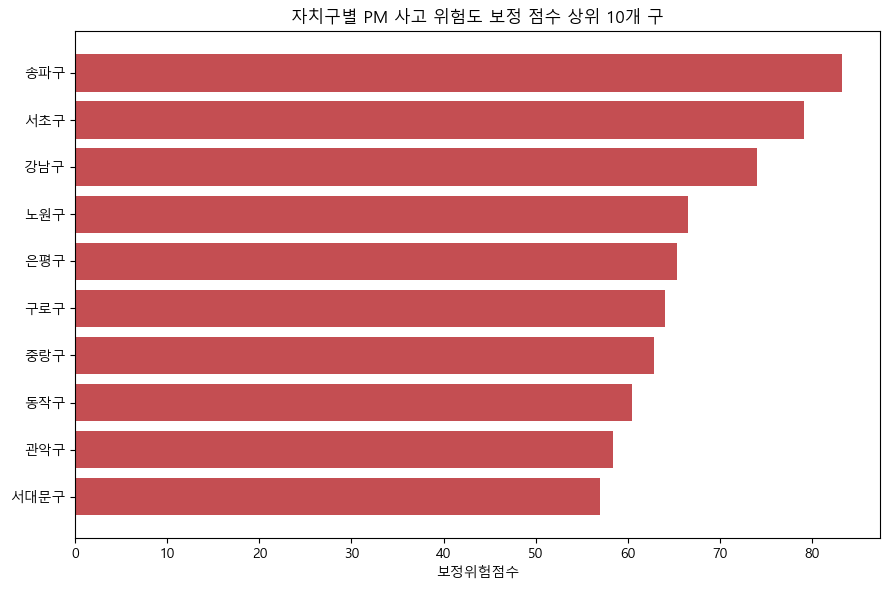

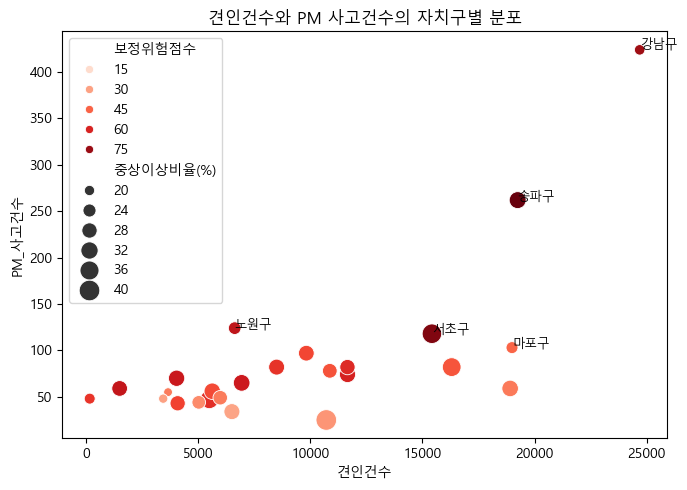

In [3]:
plot_df = risk.head(10).sort_values('보정위험점수')
plt.figure(figsize=(9, 6))
plt.barh(plot_df['자치구'], plot_df['보정위험점수'], color='#c44e52')
plt.xlabel('보정위험점수')
plt.title('자치구별 PM 사고 위험도 보정 점수 상위 10개 구')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=risk, x='견인건수', y='PM_사고건수', size='중상이상비율(%)', hue='보정위험점수', palette='Reds', sizes=(40, 220))
for _, r in risk.nlargest(5, 'PM_사고건수').iterrows():
    plt.text(r['견인건수'], r['PM_사고건수'], r['자치구'], fontsize=9)
plt.title('견인건수와 PM 사고건수의 자치구별 분포')
plt.tight_layout()
plt.show()


#### 결과 요약

| 자치구 | PM_사고건수 | 중상이상비율(%) | 견인건수 | 사고_1만견인당 | 사고_100만따릉이당 | 보정위험점수 |
| --- | --- | --- | --- | --- | --- | --- |
| 송파구 | 262.00 | 31.30 | 19249.00 | 136.11 | 20.15 | 83.23 |
| 서초구 | 118.00 | 37.29 | 15428.00 | 76.48 | 26.90 | 79.15 |
| 강남구 | 424.00 | 20.28 | 24687.00 | 171.75 | 94.65 | 74.00 |
| 노원구 | 124.00 | 23.39 | 6637.00 | 186.83 | 14.45 | 66.50 |
| 은평구 | 59.00 | 28.81 | 1509.00 | 390.99 | 16.02 | 65.33 |
| 구로구 | 70.00 | 30.00 | 4048.00 | 172.92 | 12.24 | 64.00 |
| 중랑구 | 65.00 | 30.77 | 6947.00 | 93.57 | 15.85 | 62.81 |
| 동작구 | 74.00 | 29.73 | 11666.00 | 63.43 | 25.21 | 60.46 |

- raw 사고 건수만 보면 공유 모빌리티 활동량이 많은 자치구가 상위에 오르는 경향이 있습니다.
- 견인 건수와 따릉이 이용량으로 나누어 보정하면, 단순 수요 집중 지역과 사고 위험이 상대적으로 높은 지역을 구분할 수 있습니다.
- 이 점수는 공식 위험지수가 아니라 보고서용 탐색 지표입니다. 따라서 `자치구별 위험 집중도 비교`로 표현하는 것이 적절합니다.